# Time Series forecasting with Facebook Prophet

## What you'll learn in this course

With Machine Learning comes very specific data: Time series. That type of data should be treated very specifically. In this course, you'll learn:

- How to handle Time Series data
- What are the common models
- Create time series forecasting with Prophet
- The model behind Prophet
- Include seasonality, holidays and other specific events in your forecast


## What are Time Series 🤔🤔

Simply put time series are data based on time. For example you can have:

- Sales forecast
- Spread of a virus over time
- Stock prices prediction
- Weather forecasting
- ...


## Models associated with Time Series 📈📈

When you are doing time series forecasting. You can use plenty different types of models. Among the most popular are:

- Moving averages
- Auto-correlations
- Autoregressive Integrated Moving Average (ARIMA)

## Facebook Prophet 🔮🔮

Prophet is an open source project used for Time Series Forecasting. Basically, Prophet rely on three components:

$y(t) = g(t) + s(t) + h(t) + \varepsilon_{t}$

where

$y(t)$ - forecast

$g(t)$ - trend

$s(t)$ - seasonality or periodical changes

$h(t)$ - holidays

$\varepsilon_{t}$ - Noise

We'll review each of these components in this course.


## Install Prophet

<Note type="warning" title="Installation and running">

The latest version of Prophet can't be installed on JULIE's workspaces. The following code examples have to be executed in [Google colab](https://colab.research.google.com/)

</Note>


## Example with Finance Data

For the rest of the course, we'll be using financial data from Yahoo and its `yfinance` library


In [ ]:
# pip install -q prophet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import prophet

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

# setting Jedha color palette as default
pio.templates["jedha"] = go.layout.Template(
    layout_colorway=[
        "#4B9AC7",
        "#4BE8E0",
        "#9DD4F3",
        "#97FBF6",
        "#2A7FAF",
        "#23B1AB",
        "#0E3449",
        "#015955",
    ]
)
pio.templates.default = "jedha"
pio.renderers.default = "svg"  # to be replaced by "iframe" if working on colab

In [ ]:
# !pip install -q yfinance

[*********************100%%**********************]  1 of 1 completed


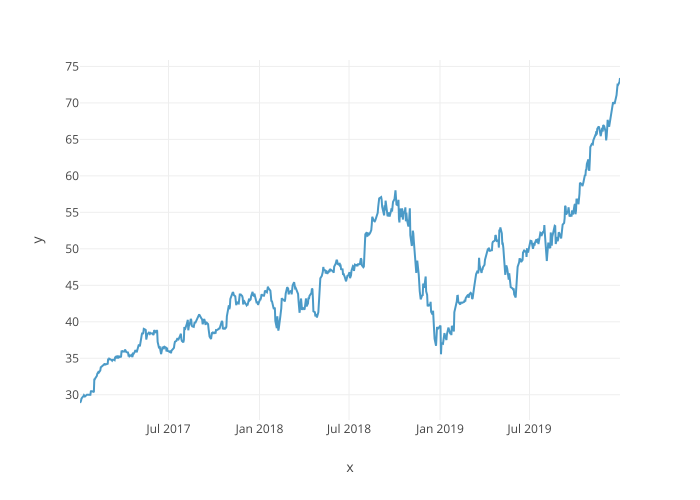

In [4]:
# Import the plotting library
import matplotlib.pyplot as plt
import yfinance as yf

# Get the data of the stock AAPL
data = yf.download("AAPL", "2017-01-01", "2020-01-01")

# Plot the close price of the AAPL
fig = px.line(x=data["Close"].index, y=data["Close"])
fig.show()

In [5]:
data

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2017-01-03,28.950001,29.082500,28.690001,29.037500,26.952713,115127600
2017-01-04,28.962500,29.127501,28.937500,29.004999,26.922546,84472400
2017-01-05,28.980000,29.215000,28.952499,29.152500,27.059448,88774400
2017-01-06,29.195000,29.540001,29.117500,29.477501,27.361118,127007600
2017-01-09,29.487499,29.857500,29.485001,29.747499,27.611732,134247600
...,...,...,...,...,...,...
2019-12-24,71.172501,71.222504,70.730003,71.067497,69.054329,48478800
2019-12-26,71.205002,72.495003,71.175003,72.477501,70.424408,93121200
2019-12-27,72.779999,73.492500,72.029999,72.449997,70.397667,146266000


Our goal is going to predict future stock prices of Apple Inc.


## Forecasting 🧙‍♂️🧙‍♂️

The best thing about Prophet is that it follows the same principles as `sklearn`. Making it very easy to use. Let's show a quick example.

First Prophet needs to receive a DataFrame with the:

- `ds` column corresponding to the time in YYYY-MM-DD format
- `y` column corresponding to your target variable


In [6]:
import pandas as pd

# Format a dataframe for Prophet where you need to have a 'ds' column for time and 'y' column for prediction

p_df = pd.DataFrame({"ds": data.index, "y": data["Open"]}).reset_index(drop=True)

p_df["ds"] = p_df["ds"].dt.tz_localize(
    None
)  # remove timezone for compatibility with latest version of prophet

p_df.head()

,ds,y
0,2017-01-03,28.950001
1,2017-01-04,28.962500
2,2017-01-05,28.980000
3,2017-01-06,29.195000
4,2017-01-09,29.487499


Next, we'll instanciate a `Prophet` instance and `fit` it to our DataFrame


In [7]:
from prophet import Prophet

m = Prophet()
m.fit(p_df)

12:23:13 - cmdstanpy - INFO - Chain [1] start processing
12:23:13 - cmdstanpy - INFO - Chain [1] done processing


Now we'll create predictions for future dates with Prophet


In [8]:
future = m.make_future_dataframe(periods=100)  # We create 100 more days
future

,ds
0,2017-01-03
1,2017-01-04
2,2017-01-05
3,2017-01-06
4,2017-01-09
...,...
849,2020-04-05
850,2020-04-06
851,2020-04-07
852,2020-04-08


Let's make our predictions


In [9]:
forecast = m.predict(future)
forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
849,2020-04-05,77.872647,76.669786,86.866858,72.802088,82.566692,3.939662,3.939662,3.939662,0.690594,0.690594,0.690594,3.249068,3.249068,3.249068,0.0,0.0,0.0,81.812310
850,2020-04-06,77.966302,75.483001,86.013168,72.769351,82.735589,2.798621,2.798621,2.798621,-0.388602,-0.388602,-0.388602,3.187223,3.187223,3.187223,0.0,0.0,0.0,80.764923
851,2020-04-07,78.059957,75.422484,86.254451,72.770837,82.866039,2.820128,2.820128,2.820128,-0.300272,-0.300272,-0.300272,3.120400,3.120400,3.120400,0.0,0.0,0.0,80.880084
852,2020-04-08,78.153611,75.665285,85.905996,72.810551,83.030841,2.823185,2.823185,2.823185,-0.226345,-0.226345,-0.226345,3.049529,3.049529,3.049529,0.0,0.0,0.0,80.976796
853,2020-04-09,78.247266,75.520929,86.174446,72.872480,83.213887,2.753834,2.753834,2.753834,-0.221840,-0.221840,-0.221840,2.975674,2.975674,2.975674,0.0,0.0,0.0,81.001100


And finally plot the results with plotly


/Users/mehdisemar/anaconda3/lib/python3.11/site-packages/prophet/plot.py:72: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

/Users/mehdisemar/anaconda3/lib/python3.11/site-packages/prophet/plot.py:73: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



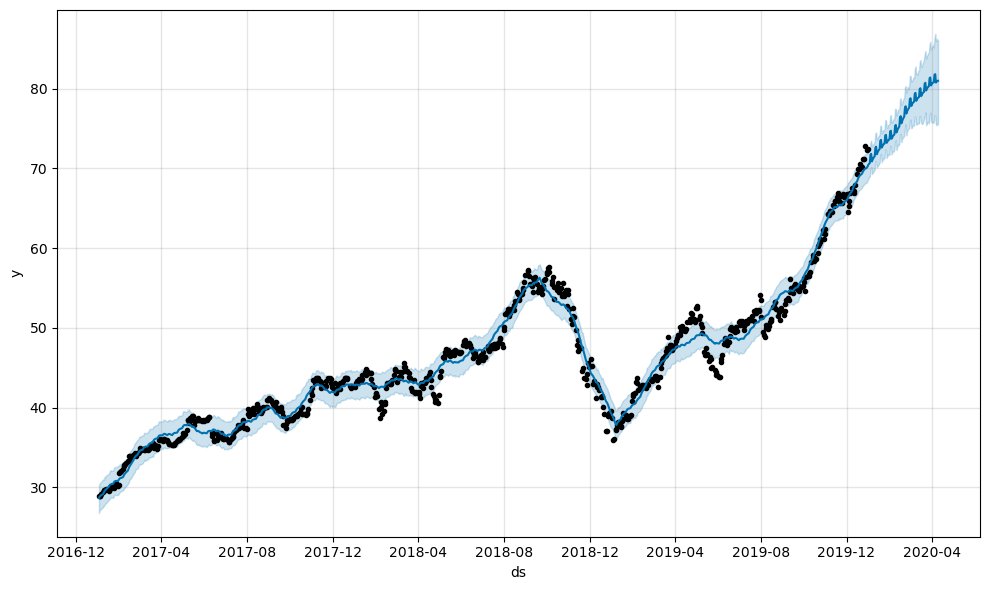

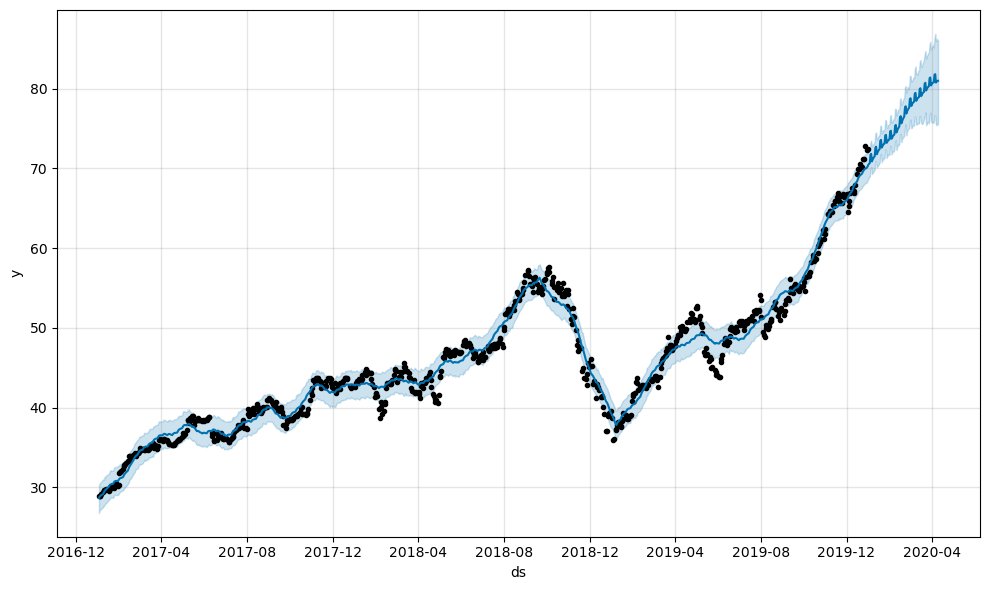

In [10]:
m.plot(forecast)

You can also plot each components of your trend. So that you can see the seasonality.


/Users/mehdisemar/anaconda3/lib/python3.11/site-packages/prophet/plot.py:228: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

/Users/mehdisemar/anaconda3/lib/python3.11/site-packages/prophet/plot.py:351: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

/Users/mehdisemar/anaconda3/lib/python3.11/site-packages/prophet/plot.py:354: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



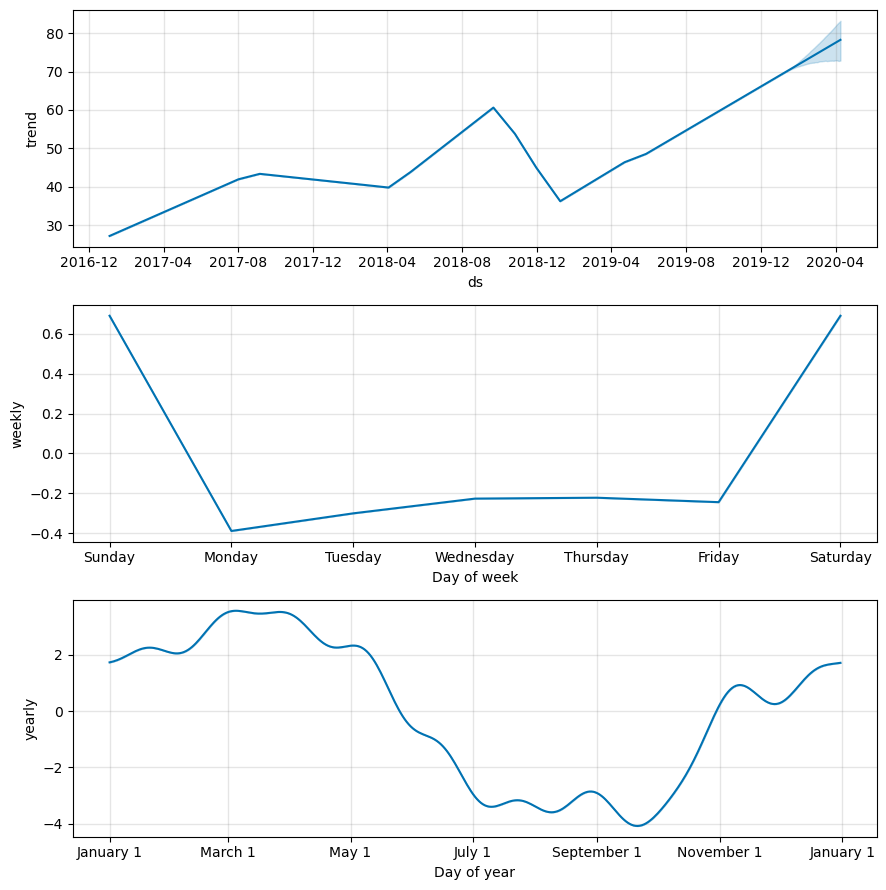

In [11]:
fig2 = m.plot_components(forecast)

## Handle Seasonality

One very cool feature that you can use with Prophet is to add seasonality. For example, you can add country holidays.


In [12]:
m = Prophet()
m.add_country_holidays(country_name="US")
m.fit(p_df)

12:23:14 - cmdstanpy - INFO - Chain [1] start processing
12:23:14 - cmdstanpy - INFO - Chain [1] done processing


Check all the added holidays


In [13]:
m.train_holiday_names

0                 New Year's Day
1      New Year's Day (observed)
2                   Memorial Day
3               Independence Day
4                      Labor Day
5                   Veterans Day
6        Veterans Day (observed)
7                   Thanksgiving
8                  Christmas Day
9     Martin Luther King Jr. Day
10         Washington's Birthday
11                  Columbus Day
dtype: object

Check now its impact on your forecast


/Users/mehdisemar/anaconda3/lib/python3.11/site-packages/prophet/plot.py:228: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

/Users/mehdisemar/anaconda3/lib/python3.11/site-packages/prophet/plot.py:351: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

/Users/mehdisemar/anaconda3/lib/python3.11/site-packages/prophet/plot.py:354: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



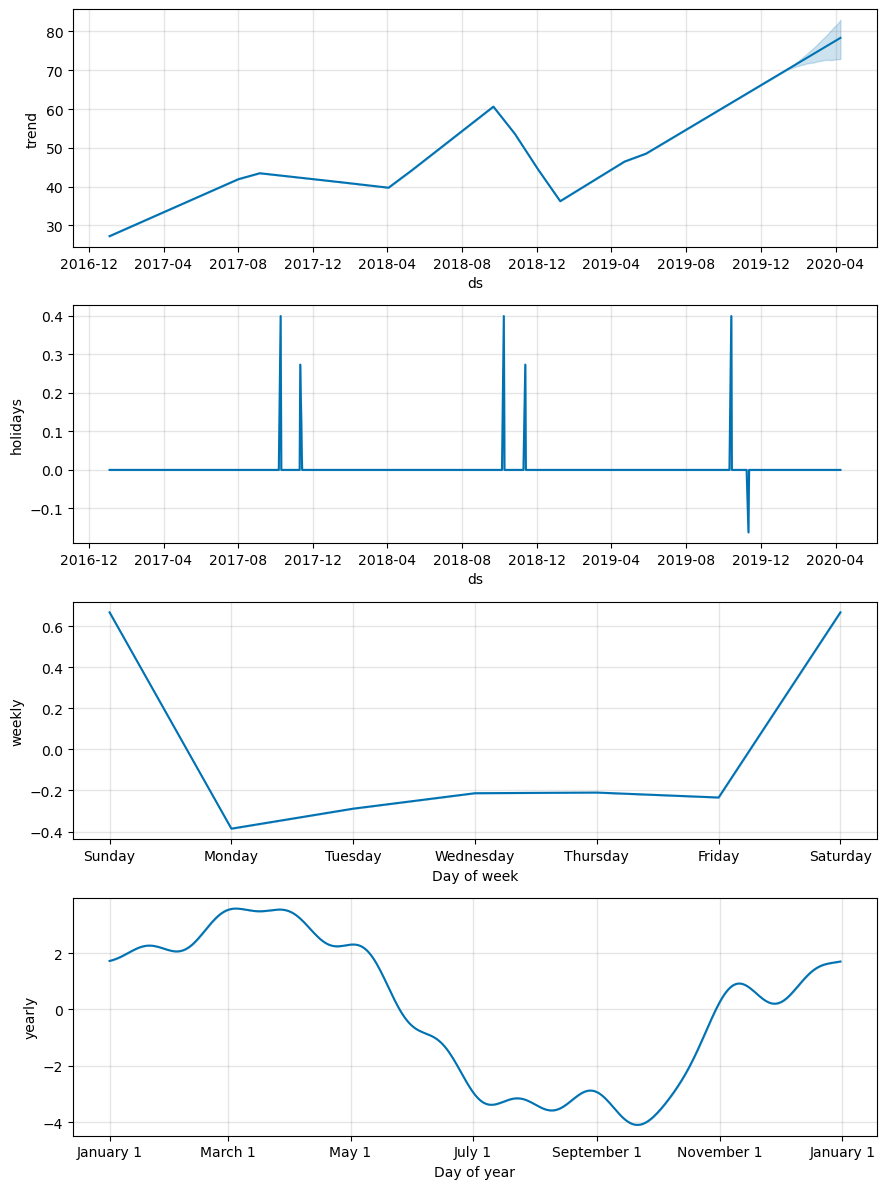

In [14]:
forecast = m.predict(future)
fig = m.plot_components(forecast)

You can also add manual holidays by providing a `holidays` DataFrame


In [15]:
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,Christmas Day,Christmas Day_lower,Christmas Day_upper,Columbus Day,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2017-01-03,27.199268,26.946581,30.495749,27.199268,27.199268,0.0,0.0,0.0,0.0,...,-0.288825,-0.288825,-0.288825,1.758982,1.758982,1.758982,0.0,0.0,0.0,28.669425
1,2017-01-04,27.269347,27.186777,30.673886,27.269347,27.269347,0.0,0.0,0.0,0.0,...,-0.213620,-0.213620,-0.213620,1.783956,1.783956,1.783956,0.0,0.0,0.0,28.839683
2,2017-01-05,27.339426,27.151919,30.651567,27.339426,27.339426,0.0,0.0,0.0,0.0,...,-0.210448,-0.210448,-0.210448,1.812139,1.812139,1.812139,0.0,0.0,0.0,28.941117
3,2017-01-06,27.409505,27.363984,30.619707,27.409505,27.409505,0.0,0.0,0.0,0.0,...,-0.234546,-0.234546,-0.234546,1.843362,1.843362,1.843362,0.0,0.0,0.0,29.018321
4,2017-01-09,27.619741,27.313180,30.897492,27.619741,27.619741,0.0,0.0,0.0,0.0,...,-0.386119,-0.386119,-0.386119,1.951344,1.951344,1.951344,0.0,0.0,0.0,29.184966
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
849,2020-04-05,77.965225,76.405801,86.471037,72.848572,82.154418,0.0,0.0,0.0,0.0,...,0.666779,0.666779,0.666779,3.263337,3.263337,3.263337,0.0,0.0,0.0,81.895340
850,2020-04-06,78.059415,75.036605,85.785198,72.841922,82.336829,0.0,0.0,0.0,0.0,...,-0.386119,-0.386119,-0.386119,3.200071,3.200071,3.200071,0.0,0.0,0.0,80.873367
851,2020-04-07,78.153605,75.212856,86.095385,72.840101,82.519237,0.0,0.0,0.0,0.0,...,-0.288825,-0.288825,-0.288825,3.131760,3.131760,3.131760,0.0,0.0,0.0,80.996540
852,2020-04-08,78.247795,75.178082,85.900968,72.860897,82.775085,0.0,0.0,0.0,0.0,...,-0.213620,-0.213620,-0.213620,3.059344,3.059344,3.059344,0.0,0.0,0.0,81.093520


In [16]:
thanksgiving = pd.DataFrame(
    {
        "holiday": "thanksgiving",
        "ds": pd.to_datetime(["2017-11-26", "2018-11-26", "2019-11-26"]),
        "lower_window": 0,
        "upper_window": 1,
    }
)

m = Prophet(holidays=thanksgiving)
# m.add_country_holidays(country_name='US')
m.fit(p_df)

12:23:15 - cmdstanpy - INFO - Chain [1] start processing
12:23:15 - cmdstanpy - INFO - Chain [1] done processing


In [17]:
thanksgiving

,holiday,ds,lower_window,upper_window
0,thanksgiving,2017-11-26,0,1
1,thanksgiving,2018-11-26,0,1
2,thanksgiving,2019-11-26,0,1


Let's check the impact of a holiday simply by checking if we have positive or negative correlations in our prediction dataframe.


In [18]:
forecast = m.predict(future)

In [19]:
forecast[forecast["ds"] == "2017-11-27"]["thanksgiving"]

227   -0.136033
Name: thanksgiving, dtype: float64

In [20]:
forecast.thanksgiving.value_counts()

thanksgiving
 0.000000    849
-0.136033      3
-0.665328      2
Name: count, dtype: int64

## Multi-variate forecasting

Sometimes, you might want to create forecast not only with times but with also other variables. Prophet calls it Regressors. To add a regressor, you can simply do:


In [21]:
# Get the data of Microsoft Stock
msft = yf.download("MSFT", "2017-01-01", "2020-01-01")

# Preprocess the data
msft = pd.DataFrame({"ds": msft.index, "msft_stock_price": msft["Open"]}).reset_index(
    drop=True
)


msft.head()

[*********************100%%**********************]  1 of 1 completed


,ds,msft_stock_price
0,2017-01-03,62.790001
1,2017-01-04,62.480000
2,2017-01-05,62.189999
3,2017-01-06,62.299999
4,2017-01-09,62.759998


Let's incorporate this column in our DataFrame


In [22]:
p_df["msft_stock_price"] = msft["msft_stock_price"]
p_df.head()

,ds,y,msft_stock_price
0,2017-01-03,28.950001,62.790001
1,2017-01-04,28.962500,62.480000
2,2017-01-05,28.980000,62.189999
3,2017-01-06,29.195000,62.299999
4,2017-01-09,29.487499,62.759998


In [23]:
m = Prophet()
m.add_regressor("msft_stock_price")

However, once you added a regressor, you absolutely need to have it in your train set AND in your predictions. Therefore, let's split our dataset


In [24]:
# Train_test_split
train_size = int(0.8 * len(p_df))


X_train = p_df.iloc[:train_size, :]
X_test = p_df.iloc[train_size:, :]

X_train.head()

,ds,y,msft_stock_price
0,2017-01-03,28.950001,62.790001
1,2017-01-04,28.962500,62.480000
2,2017-01-05,28.980000,62.189999
3,2017-01-06,29.195000,62.299999
4,2017-01-09,29.487499,62.759998


In [25]:
m.fit(X_train)

12:23:15 - cmdstanpy - INFO - Chain [1] start processing
12:23:16 - cmdstanpy - INFO - Chain [1] done processing


/Users/mehdisemar/anaconda3/lib/python3.11/site-packages/prophet/plot.py:72: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

/Users/mehdisemar/anaconda3/lib/python3.11/site-packages/prophet/plot.py:73: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



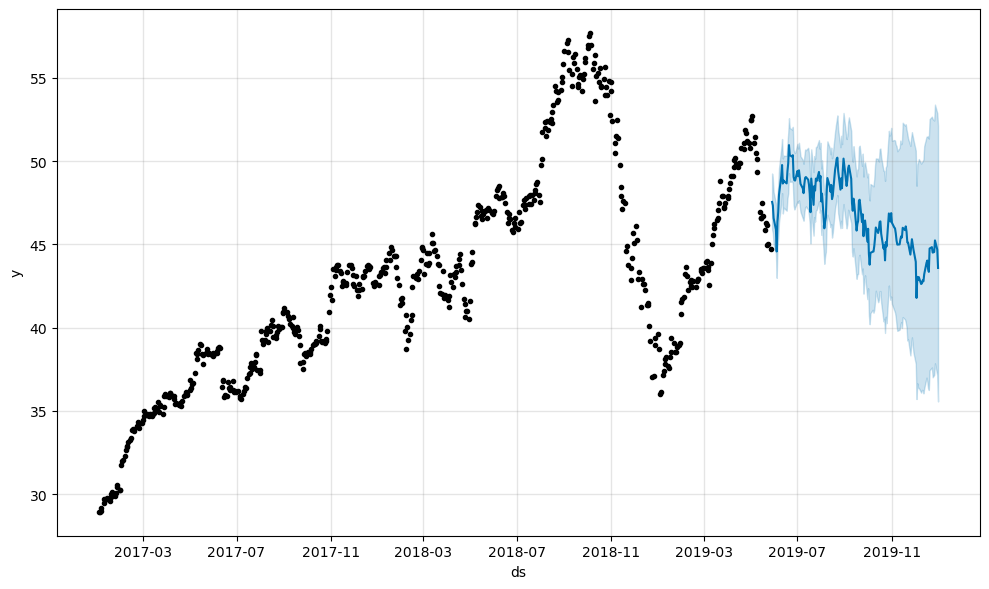

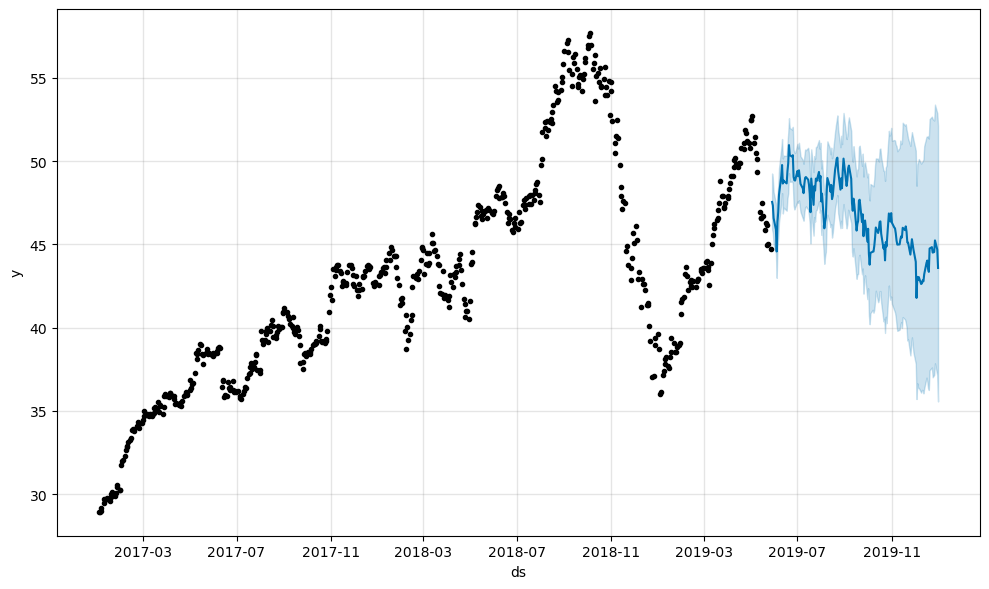

In [26]:
# Forecast
forecast = m.predict(X_test)

# Viz
m.plot(forecast)

In [27]:
future = m.make_future_dataframe(periods=1)
future

,ds
0,2017-01-03
1,2017-01-04
2,2017-01-05
3,2017-01-06
4,2017-01-09
...,...
599,2019-05-22
600,2019-05-23
601,2019-05-24
602,2019-05-28


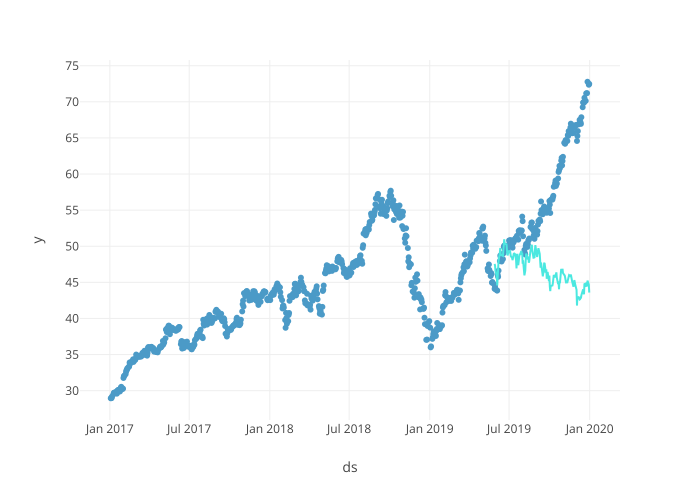

In [28]:
fig = px.scatter(p_df, x="ds", y="y")
fig.add_trace(px.line(forecast, x="ds", y="yhat").data[0])
fig["data"][1]["line"]["color"] = "#4BE8E0"
fig.show()

## Resources

- [Seasonality, Holiday Effects, And Regressors](https://facebook.github.io/prophet/docs/seasonality,_holiday_effects,_and_regressors.html#additional-regressors)
- [Forecasting at Scale](https://peerj.com/preprints/3190/)
- [Introduction to Time Series Analysis](https://www.itl.nist.gov/div898/handbook/pmc/section4/pmc4.htm)
- [Time Series](https://en.wikipedia.org/wiki/Time_series#:~:text=A%20time%20series%20is%20a,sequence%20of%20discrete%2Dtime%20data.)
